# 5.5 Another Inverse Problem for Boundary Value Problem

In [60]:
using CairoMakie
using LinearAlgebra
using LinearSolve
using SparseArrays
using BenchmarkTools
using CSV
using DataFrames

In this notebook, you are given that some data is taken from a beam deflection

You are given some data points, which is the deflection, $y_i$ at each location $x_i$, $(x_i,y_i)$.  Your task is to find $w(x)$ that fits this data.  

As always, let's ready the  $(x_i,y_i)$ data points and see how they look like.   

In [61]:
df = CSV.read("Data02.csv", DataFrame;
select=["xdata", "ydata"])
xdata=df[:, :xdata]
ydata=df[:, :ydata]

21-element Vector{Float64}:
  6.193274031670026e-6
 -0.006933256855191791
 -0.013793416340386966
 -0.020139566083147084
 -0.02592585842298292
 -0.0314219557421773
 -0.035695173683070854
 -0.03919257035712028
 -0.04216293620929979
 -0.04365907025456364
  ⋮
 -0.0418571567040539
 -0.039278369830890204
 -0.035606695233852036
 -0.03141672660297643
 -0.025937235385701408
 -0.019989591029609125
 -0.013792253703661665
 -0.006914322558068647
 -3.915200830436959e-5

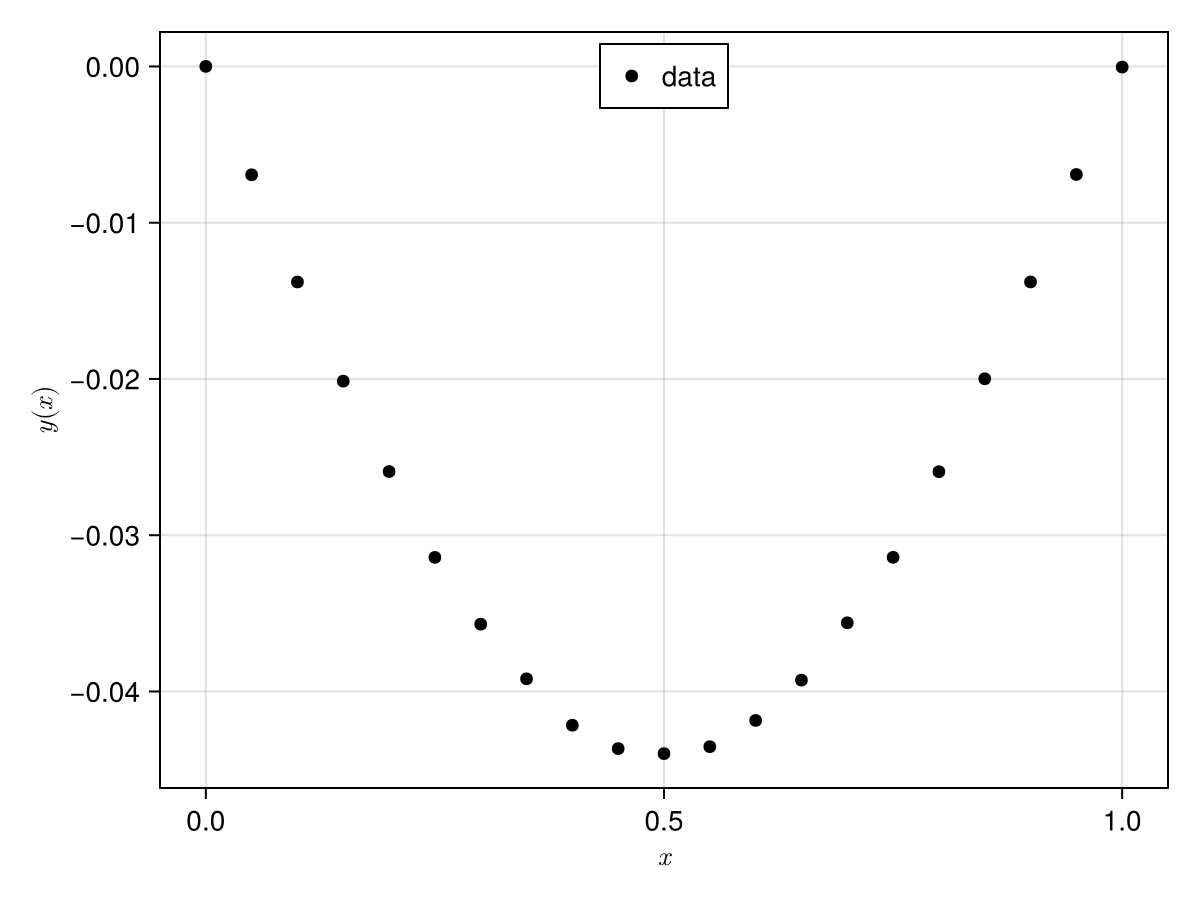

In [62]:
fig = Figure()
ax = Axis(fig[1, 1], xlabel = L"x", ylabel = L"y(x)")
scatter!(ax,xdata,ydata,color=:black,label="data")
axislegend(ax,position=:ct)
save("../figures/05p05ParameterEstimationBVP0201.svg",fig)
fig

Since we know that our data is taken from the deflection of a beam, can use what we know about the deflection of the beam.  From other parts of your degree program,  we know that a good model for the beam deflection is 

$\frac{d^2y}{dx^2}+4y(x)=w(x)$


$y$ is the deflection of the beam and $w(x)$ a weight distribution on this beam.  The domain is $x\in [0,1]$. There is no deflection at the ends of the beam, so $y(0)=y(1)=0.0$.   We can discretise this equation as per usual

$\frac{d^2y}{dx^2}\approx\frac{y_{i-1}-2y_i+y_{i+1}}{\Delta^2}$ 

the governing equation for beam deflection becomes 

$\frac{y_{i-1}-2y_i+y_{i+1}}{\Delta^2}+4y_i=w(x_i)$ 

We do not know what $w(x)$ is so we will just use a model and say

$w(x)=a_0+a_1x$

Our model becomes

$\frac{y_{i-1}-2y_i+y_{i+1}}{\Delta^2}+4y_i=w(x_i)=a_0+a_1x_i$ 

So our task now is to find $a_0$ and $a_1$ such that when you solve the the equation above, you get $y_i$ that agrees best agree with your data.  

For a domain of 5 intervals, our matrix equations will look like

$$
\begin{bmatrix}
1 & 0 & 0 & 0 & 0 &0 \\
1/\Delta^2 & -2/\Delta^2+4 & 1/\Delta^2 & 0 & 0 & 0\\
0 & 1/\Delta^2 & -2/\Delta^2 +4& 1/\Delta^2 & 0 & 0 \\
0 &  0 & 1/\Delta^2 & -2/\Delta^2+4 & 1/\Delta^2 & 0  \\
0 &  0 & 0 & 1/\Delta^2 & -2/\Delta^2 +4& 1/\Delta^2   \\
0 &  0 & 0 & 0 & -1 & 1   \\
\end{bmatrix}\begin{Bmatrix}
y_1\\
y_2\\
y_3\\
y_4\\
y_5\\
y_6\\
\end{Bmatrix}=\begin{Bmatrix}
0\\
a_0+a_1x_2\\
a_0+a_1x_3\\
a_0+a_1x_4\\
a_0+a_1x_5\\
0\\
\end{Bmatrix}
$$

Everytime with want to make a prediction, we need to solve the equation above.  With the exception of $y_1$ and $y_6$, all your $y_i$'s above are dependent on $a_0$ and $a_1$. The dependence is not explicit but there is an implicit relationship.    In terms of a model, we can think of the above equations as an implicity definition of our $f_{model}(a_0,a_1,x)$

$$
\begin{bmatrix}
1 & 0 & 0 & 0 & 0 &0 \\
1/\Delta^2 & -2/\Delta^2+4 & 1/\Delta^2 & 0 & 0 & 0\\
0 & 1/\Delta^2 & -2/\Delta^2 +4& 1/\Delta^2 & 0 & 0 \\
0 &  0 & 1/\Delta^2 & -2/\Delta^2+4 & 1/\Delta^2 & 0  \\
0 &  0 & 0 & 1/\Delta^2 & -2/\Delta^2 +4& 1/\Delta^2   \\
0 &  0 & 0 & 0 & -1 & 1   \\
\end{bmatrix}\begin{Bmatrix}
f_{model}(a_0,a_1,x_1)\\
f_{model}(a_0,a_1,x_2)\\
f_{model}(a_0,a_1,x_3)\\
f_{model}(a_0,a_1,x_4)\\
f_{model}(a_0,a_1,x_5)\\
f_{model}(a_0,a_1,x_6)\\
\end{Bmatrix}=\begin{Bmatrix}
0\\
a_0+a_1x_2\\
a_0+a_1x_3\\
a_0+a_1x_4\\
a_0+a_1x_5\\
0\\
\end{Bmatrix}
$$

Set up matrices

In [63]:
Delta=xdata[2]-xdata[1]
n=length(xdata)
d=zeros(n)
dl=zeros(n-1)
du=zeros(n-1)
C=zeros(n)
du[1]=0.0
d[1]=1.0
C[1]=0.0
for i=2:n-1
    dl[i-1]=(1.0/Delta^2)
    d[i]=-(2.0/Delta^2)+4.0
    du[i]=(1.0/Delta^2)
end
dl[n-1]=0.0
d[n]=1.0
C[n]=0.0

# Construct the specialized structured matrix
A = Tridiagonal(dl, d, du)

21×21 Tridiagonal{Float64, Vector{Float64}}:
   1.0     0.0      ⋅       ⋅       ⋅   …      ⋅       ⋅       ⋅      ⋅ 
 400.0  -796.0   400.0      ⋅       ⋅          ⋅       ⋅       ⋅      ⋅ 
    ⋅    400.0  -796.0   400.0      ⋅          ⋅       ⋅       ⋅      ⋅ 
    ⋅       ⋅    400.0  -796.0   400.0         ⋅       ⋅       ⋅      ⋅ 
    ⋅       ⋅       ⋅    400.0  -796.0         ⋅       ⋅       ⋅      ⋅ 
    ⋅       ⋅       ⋅       ⋅    400.0  …      ⋅       ⋅       ⋅      ⋅ 
    ⋅       ⋅       ⋅       ⋅       ⋅          ⋅       ⋅       ⋅      ⋅ 
    ⋅       ⋅       ⋅       ⋅       ⋅          ⋅       ⋅       ⋅      ⋅ 
    ⋅       ⋅       ⋅       ⋅       ⋅          ⋅       ⋅       ⋅      ⋅ 
    ⋅       ⋅       ⋅       ⋅       ⋅          ⋅       ⋅       ⋅      ⋅ 
   ⋮                                    ⋱                            ⋮
    ⋅       ⋅       ⋅       ⋅       ⋅          ⋅       ⋅       ⋅      ⋅ 
    ⋅       ⋅       ⋅       ⋅       ⋅          ⋅       ⋅       ⋅      ⋅ 
    ⋅   

In [64]:
function loss(p,ydata)
    
    C=(p[1].+p[2]*xdata) #this is the model for  w(x)
    C[1]=0.0
    C[n]=0.0
    prob=LinearProblem(A,C)
    fmodel=LinearSolve.solve(prob)

    return sum(0.5*(fmodel.-ydata).^2)
end

loss (generic function with 1 method)

In [65]:
function callback(state, l)
    push!(losses, l)
    if length(losses) % 50 == 0
        println("Current loss after $(length(losses)) iterations: $(losses[end])")
    end
    return false
end

callback (generic function with 1 method)

In [66]:
using Optimization
using Optimisers
using OptimizationOptimisers
using ForwardDiff

losses = Float64[]
adtype = AutoForwardDiff()
optf = OptimizationFunction(loss, adtype)
optprob = OptimizationProblem(optf,[1.0,1.0],ydata)
sol=Optimization.solve(optprob,Adam(0.001f0),maxiters=50000, callback=callback)

Current loss after 50 iterations: 0.3539833430859307
Current loss after 100 iterations: 0.3132740759759778
Current loss after 150 iterations: 0.2761963691905348
Current loss after 200 iterations: 0.24254297005130626
Current loss after 250 iterations: 0.21210706975908972
Current loss after 300 iterations: 0.18468543338663534
Current loss after 350 iterations: 0.1600786309008853
Current loss after 400 iterations: 0.13809132643842867
Current loss after 450 iterations: 0.11853262757394002
Current loss after 500 iterations: 0.10121648484972331
Current loss after 550 iterations: 0.08596213408992455
Current loss after 600 iterations: 0.07259457313155045
Current loss after 650 iterations: 0.06094506273029749
Current loss after 700 iterations: 0.05085163924789153
Current loss after 750 iterations: 0.042159624638664094
Current loss after 800 iterations: 0.034722117477979694
Current loss after 850 iterations: 0.028400447541949203
Current loss after 900 iterations: 0.023064575965280592
Current los

retcode: Default
u: 2-element Vector{Float64}:
  0.20498827173069406
 -0.0037530785003483157

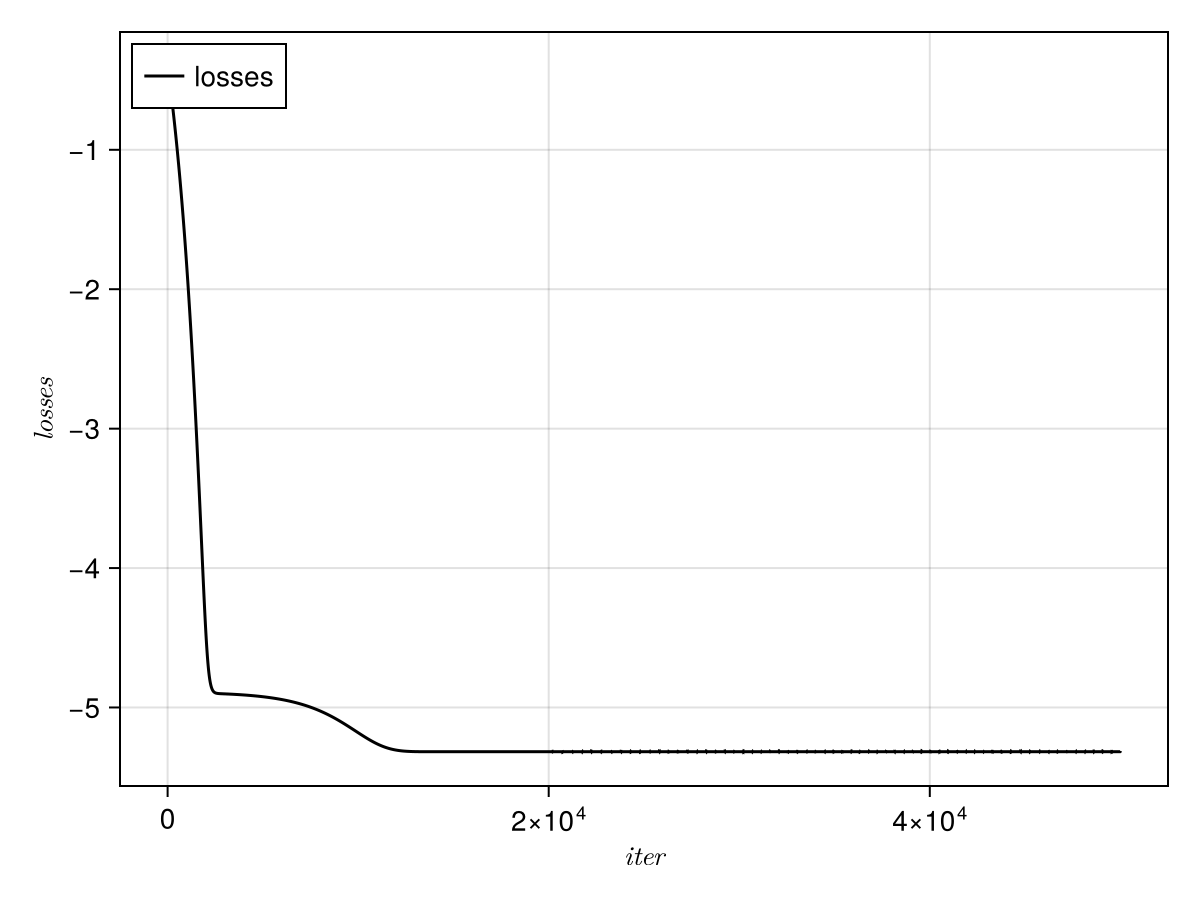

In [67]:
fig = Figure()
ax = Axis(fig[1, 1], xlabel = L"iter", ylabel = L"losses")
lines!(ax,log10.(losses),color=:black,label="losses")
axislegend(ax,position=:lt)
fig

In [68]:
sol.u

2-element Vector{Float64}:
  0.20498827173069406
 -0.0037530785003483157

In [69]:
    C=(sol.u[1].+sol.u[2]*xdata)
    C[1]=0.0
    C[n]=0.0
    prob=LinearProblem(A,C)
    ymodel=LinearSolve.solve(prob)

retcode: Success
u: 21-element Vector{Float64}:
  7.616129948928575e-16
 -0.007666175046836071
 -0.014743686798690352
 -0.021162229272856083
 -0.026858086179404144
 -0.0317747680840816
 -0.035863577302654215
 -0.03908409487774881
 -0.04140458476842699
 -0.042802311210594496
  ⋮
 -0.04137068358298595
 -0.039036015321823644
 -0.035804614980679425
 -0.03170926569777728
 -0.026791390100758775
 -0.02110063608040664
 -0.014694380311736937
 -0.007637154487248917
  0.0

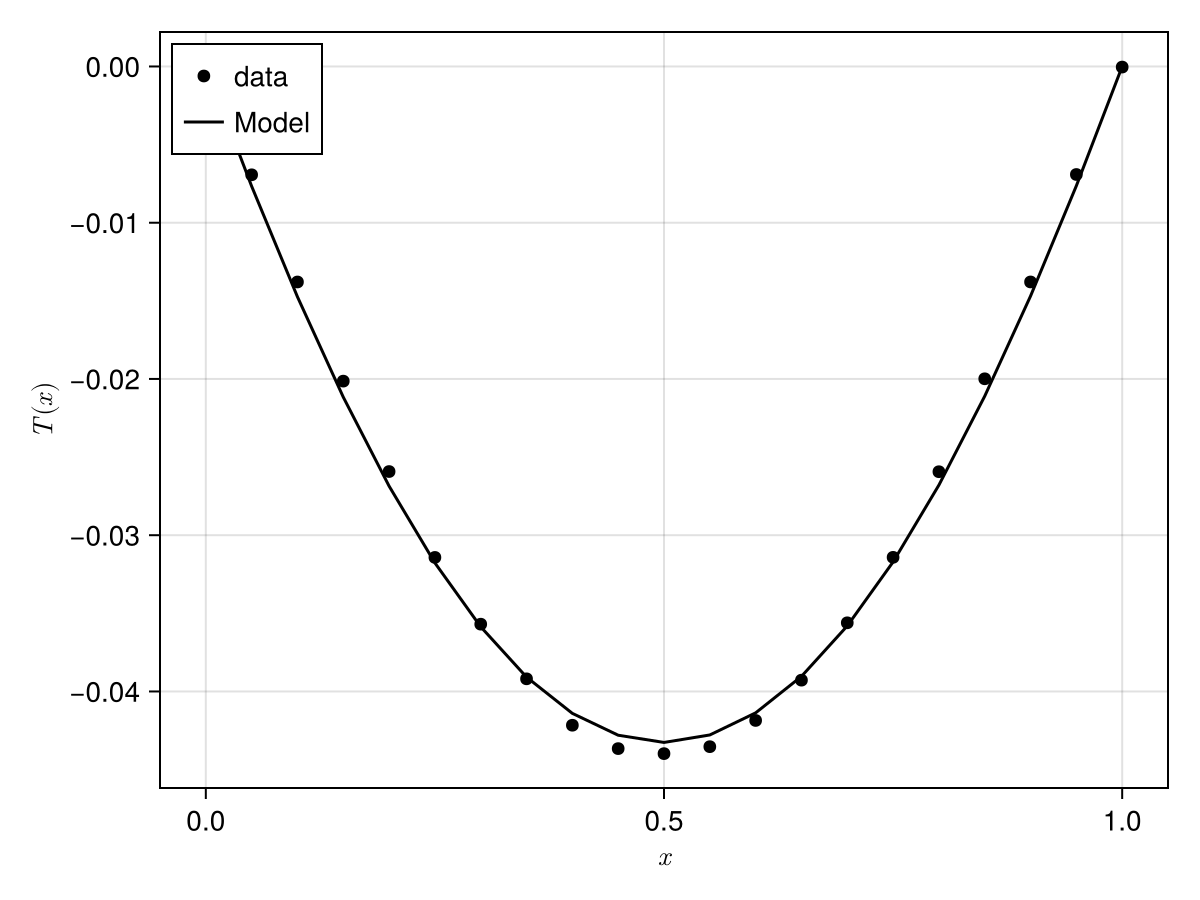

In [70]:
fig = Figure()
ax = Axis(fig[1, 1], xlabel = L"x", ylabel = L"T(x)")
scatter!(ax,xdata,ydata,color=:black,label="data")
lines!(ax,xdata,ymodel,color=:black,label="Model")
axislegend(ax,position=:lt)
fig

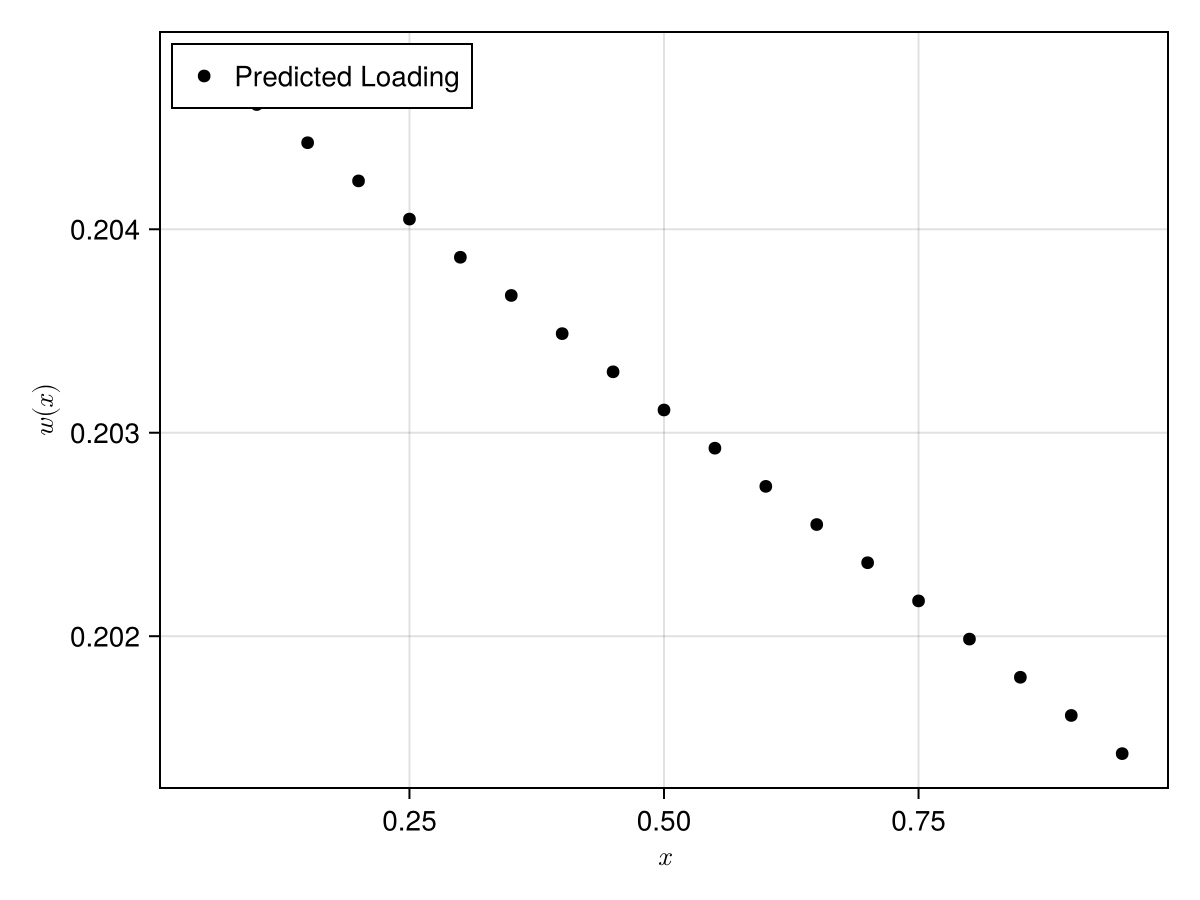

In [71]:
fig = Figure()
ax = Axis(fig[1, 1], xlabel = L"x", ylabel = L"w(x)")
scatter!(ax,xdata[2:end-1],C[2:end-1],color=:black,label="Predicted Loading")
axislegend(ax,position=:lt)
fig

In [72]:
sol.u

2-element Vector{Float64}:
  0.20498827173069406
 -0.0037530785003483157

---

**Class Exercise:** Now try to model the data using simple polynomial.  

$f_{model}(\vec{a},x)=a_0+a_1x+a_2x^2+a_3x^3+...$

What are the values of $\vec{a}$ that best fit this data?